In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("ds_salaries.csv")

In [5]:
df.head() 

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [6]:
df.shape

(3755, 11)

In [7]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='str')

In [10]:
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
work_year,3755.0,2022.373635,0.691448,2020.0,2022.0,2022.0,2023.0,2023.0
salary,3755.0,190695.571771,671676.500508,6000.0,100000.0,138000.0,180000.0,30400000.0
salary_in_usd,3755.0,137570.389880,63055.625278,5132.0,95000.0,135000.0,175000.0,450000.0
remote_ratio,3755.0,46.271638,48.589050,0.0,0.0,0.0,100.0,100.0


In [11]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,3755.0,NaN,NaN,NaN,2022.373635,0.691448,2020.0,2022.0,2022.0,2023.0,2023.0
experience_level,3755,4,SE,2516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,3755,4,FT,3718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,3755,93,Data Engineer,1040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,3755.0,NaN,NaN,NaN,190695.571771,671676.500508,6000.0,100000.0,138000.0,180000.0,30400000.0
salary_currency,3755,20,USD,3224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,3755.0,NaN,NaN,NaN,137570.38988,63055.625278,5132.0,95000.0,135000.0,175000.0,450000.0
employee_residence,3755,78,US,3004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,3755.0,NaN,NaN,NaN,46.271638,48.58905,0.0,0.0,0.0,100.0,100.0
company_location,3755,72,US,3040,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           3755 non-null   int64
 1   experience_level    3755 non-null   str  
 2   employment_type     3755 non-null   str  
 3   job_title           3755 non-null   str  
 4   salary              3755 non-null   int64
 5   salary_currency     3755 non-null   str  
 6   salary_in_usd       3755 non-null   int64
 7   employee_residence  3755 non-null   str  
 8   remote_ratio        3755 non-null   int64
 9   company_location    3755 non-null   str  
 10  company_size        3755 non-null   str  
dtypes: int64(4), str(7)
memory usage: 423.6 KB


In [13]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [14]:
df.nunique()

work_year                4
experience_level         4
employment_type          4
job_title               93
salary                 815
salary_currency         20
salary_in_usd         1035
employee_residence      78
remote_ratio             3
company_location        72
company_size             3
dtype: int64

In [20]:
categorical_columns = df.select_dtypes('str').columns
categorical_columns

Index(['experience_level', 'employment_type', 'job_title', 'salary_currency',
       'employee_residence', 'company_location', 'company_size'],
      dtype='str')

In [22]:
numerical_columns = df.select_dtypes('int').columns
numerical_columns

Index(['work_year', 'salary', 'salary_in_usd', 'remote_ratio'], dtype='str')

In [16]:
Duplicate_count = df.duplicated().sum()
Total_rows = df.shape[0]

print(f"Total Rows: {Total_rows}")
print(f"Duplicated Rows: {Duplicate_count}")
print(f"Percentage: {(Duplicate_count/Total_rows)*100:.2f}%")

Total Rows: 3755
Duplicated Rows: 1171
Percentage: 31.19%


In [46]:
df.drop_duplicates(inplace=True)

In [48]:
int(df.duplicated().sum())

0

In [49]:
df['work_year'].value_counts()

work_year
2023    1156
2022    1125
2021     228
2020      75
Name: count, dtype: int64

In [50]:
df['salary'].value_counts().head(10)

salary
100000    70
120000    59
150000    58
200000    48
80000     46
130000    42
70000     42
90000     40
110000    39
50000     39
Name: count, dtype: int64

In [51]:
df['job_title'].value_counts().head(10)

job_title
Data Engineer                598
Data Scientist               538
Data Analyst                 396
Machine Learning Engineer    206
Analytics Engineer            91
Research Scientist            65
Data Architect                64
Data Science Manager          52
ML Engineer                   34
Research Engineer             33
Name: count, dtype: int64

In [53]:
df['experience_level'].value_counts()

experience_level
SE    1554
MI     664
EN     270
EX      96
Name: count, dtype: int64

In [54]:
float(df['salary_in_usd'].median())

130000.0

In [55]:
int(df['salary_in_usd'].mode()[0])

100000

In [75]:
round(float(df['salary_in_usd'].mean()),4) #to round the answer till 4 decimal places

133409.2802

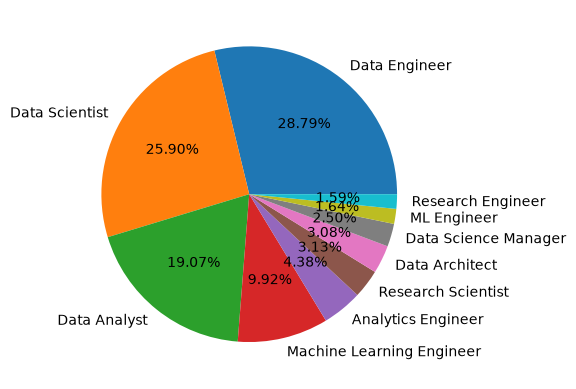

In [57]:
plt.pie(
    x=df['job_title'].value_counts().head(10).values,
    labels=df['job_title'].value_counts().head(10).index,
    autopct="%.2f%%"
)

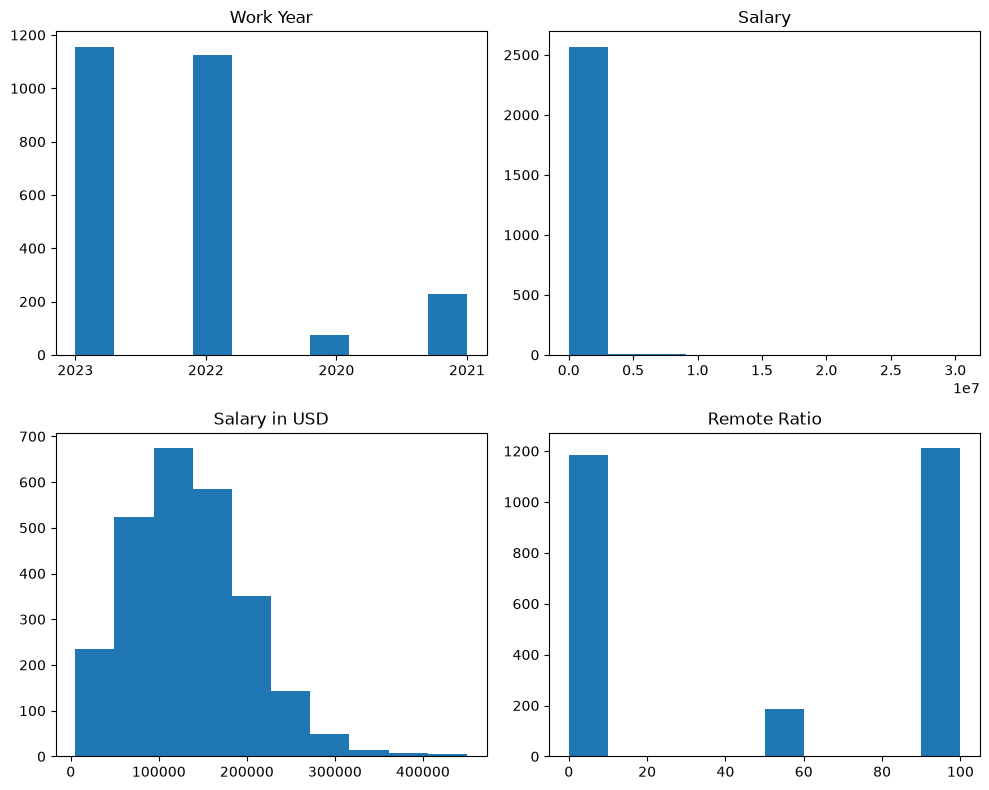

In [88]:

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.hist(df['work_year'])
plt.title("Work Year")

plt.subplot(2, 2, 2)
plt.hist(df['salary'])
plt.title("Salary")

plt.subplot(2, 2, 3)
plt.hist(df['salary_in_usd'])
plt.title("Salary in USD")

plt.subplot(2, 2, 4)
plt.hist(df['remote_ratio'])
plt.title("Remote Ratio")

plt.tight_layout() # Adjusts the spacing between subplots to prevent overlapping labels and titles.
plt.show()


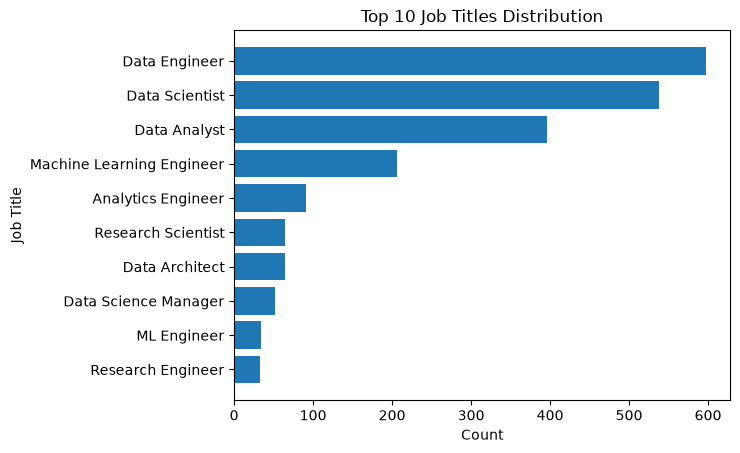

In [77]:
top_job_titles = df['job_title'].value_counts().head(10)

plt.barh(top_job_titles.index[::-1], top_job_titles.values[::-1]) #to print the bar graph in descending order

plt.title('Top 10 Job Titles Distribution')
plt.xlabel('Count')
plt.ylabel('Job Title')

plt.show()

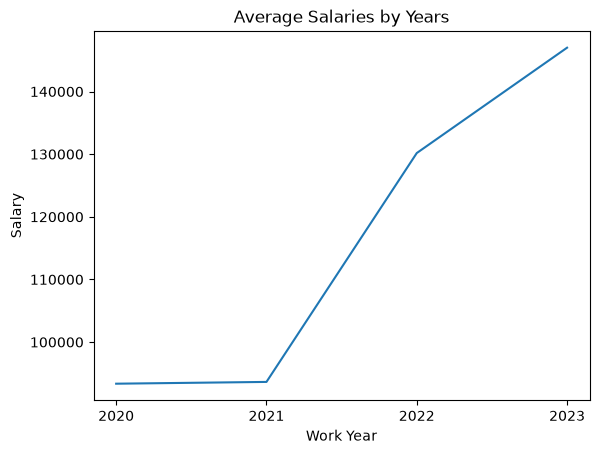

In [78]:
year_based_salary = df.groupby('work_year')['salary_in_usd'].mean()

years = year_based_salary.index.astype(int).astype(str) #.astype(int).astype(str) is used for year to be displayed as int not float

plt.plot(years, year_based_salary.values)
plt.title("Average Salaries by Years")
plt.xlabel("Work Year")
plt.ylabel("Salary")

plt.show()